[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/03a_baseline.ipynb)

# 03a — Baseline Experiment: Random Search and a Rule-Based Sweep

## 1. Overview

This notebook evaluates two **baseline optimization methods** for multi-band antenna tilt coordination: choosing one
tilt per `(cell, band)` pair to improve coverage while limiting co-band overlap. The baselines are
the reference TuRBO (notebook 03b) is read against.

**Goals.**

- Run two simple, reproducible baselines on the same simulator, scenario and objective as TuRBO.
- Measure what they change on every KPI, and where on the map.
- Set the reference performance level for the method comparison in notebook 04.

The problem formulation (the tilt vector and its bounds) and the KPI definitions are described in notebook 01
(sections 2, 7, 8 and 12) and are not repeated here.

**Outputs.** One run directory per method and seed under `outputs/optim/`, tables under
`reports/tables/03a_baseline/`, figures under `reports/figures/03a_baseline/`. **Requirements.** A CUDA GPU.
The shell equivalent of the runs is `task baseline` (random search) and `task baseline -- optim/method=rule`.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core"), ("sionna.rt", "sionna-rt")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.config import load_config
from src.evaluation import compare, maps, plots
from src.evaluation import runs as run_store
from src.evaluation.export import readable, save_table
from src.kpi.capacity import max_rsrp
from src.kpi.overlap import overlap_neighbors
from src.optim.objective import MAXIMISED
from src.optim.run import run
from src.optim.space import TiltSpace
from src.utils.plotting import label, save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/03a_baseline"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/03a_baseline"))
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

# Search seeds: optim.seed from the config; BAND_TILT_SEEDS (space-separated) overrides it.
SEEDS = [int(seed) for seed in os.environ.get("BAND_TILT_SEEDS", str(cfg.optim.seed)).split()]
METHODS = ("random", "rule")

## 2. Baseline Methods

### Random search (`optim/method=random`)

Scrambled Sobol points drawn uniformly over the tilt box, each ray-traced and scored; the configuration with the
highest objective is kept. It is matched to TuRBO on the evaluation budget and seed, and its first `n_init` points
are TuRBO's initial design, so any gap between the two is what the model contributes.

### Rule-based sweep (`optim/method=rule`)

The operator heuristic: every cell on a band shares one tilt, and the band tilts are tuned by coordinate descent,
trying `n_steps` values per band per pass over `n_rounds` passes. It is deterministic and not budget-matched.

### Why these baselines?

- Neither needs a learned model.
- Both are straightforward to reproduce from a seed and a config.
- Random search makes no assumption about the objective landscape; the sweep encodes the one an operator would make.
- Together they bound what TuRBO has to beat: an unstructured search at equal budget and a structured one at far
  lower cost.

## 3. Experimental Setup

Every value below is read from the composed config and the simulation output, not restated by hand.

In [3]:
space = TiltSpace.from_config(cfg)
baseline = run_store.baseline_map(cfg)
cells = pd.read_parquet(cfg.data.output.cell_file).drop_duplicates("cell")
ue = pd.read_parquet(cfg.data.output.ue_file)
radio_cfg = cfg.simulation.radio_map
n_rows, n_cols = maps.grid_shape(baseline)

network = pd.DataFrame(
    {
        "Parameter": [
            "Sites (nodes)",
            "Cells",
            "Frequency bands",
            "Optimized variables",
            "Tilt range [°]",
            "Current tilt [°]",
            "Tilt step, maximum tilt change",
        ],
        "Value": [
            cells["node"].nunique(),
            len(space.cells),
            ", ".join(label(band) for band in space.band_names),
            f"{space.n_dim} ({len(space.cells)} cells x {len(space.band_names)} bands)",
            f"{space.lower.min():g} – {space.upper.max():g}",
            ", ".join(f"{value:g}" for value in np.unique(space.baseline)),
            "Not constrained: continuous tilt inside the box",
        ],
    }
)
mechanisms = [
    name
    for name in ("los", "specular_reflection", "diffuse_reflection", "refraction", "diffraction")
    if bool(radio_cfg[name])
]
simulation = pd.DataFrame(
    {
        "Parameter": [
            "Simulator",
            "Scene",
            "Scenario",
            "Grid resolution [m]",
            "Evaluation tiles",
            "Rays per transmitter",
            "Maximum path depth",
            "Propagation mechanisms",
        ],
        "Value": [
            "Sionna RT",
            str(cfg.simulation.scene.name),
            str(baseline["scenario_id"]),
            f"{float(baseline['tile_size_m']):g}",
            f"{n_rows * n_cols} ({n_rows} x {n_cols})",
            f"{int(radio_cfg.samples_per_tx):,}",
            int(radio_cfg.max_depth),
            ", ".join(mechanisms),
        ],
    }
)
users = pd.DataFrame(
    {
        "Parameter": ["UE reports", "Intervals", "Distribution"],
        "Value": [
            len(ue),
            ue["t_index"].nunique(),
            "Uniform open-ground background plus Gaussian hotspots (notebook 00)",
        ],
    }
)
for name, table in (("network", network), ("simulation", simulation), ("users", users)):
    save_table(table, f"setup_{name}")
    display(table)

,Parameter,Value
0,Sites (nodes),4
1,Cells,12
2,Frequency bands,"2600 MHz, 1800 MHz, 700 MHz"
3,Optimized variables,36 (12 cells x 3 bands)
4,Tilt range [°],0 – 15
5,Current tilt [°],"6, 9, 12"
6,"Tilt step, maximum tilt change",Not constrained: continuous tilt inside the box


,Parameter,Value
0,Simulator,Sionna RT
1,Scene,data/external/scene/scene.xml
2,Scenario,scn_7d938e15f9ac4618
3,Grid resolution [m],20
4,Evaluation tiles,101060 (326 x 310)
5,Rays per transmitter,"10,000,000"
6,Maximum path depth,8
7,Propagation mechanisms,"los, specular_reflection, refraction"


,Parameter,Value
0,UE reports,10066
1,Intervals,672
2,Distribution,Uniform open-ground background plus Gaussian h...


Every candidate is scored on all UEs, so the numbers from section 6 onwards are the search's own measurements.

## 4. Baseline Configuration

Both methods start from the committed network configuration, which is always evaluation 0 of a run.

In [4]:
def method_config(method):
    return load_config(overrides=[f"optim/method={method}", *CONFIG_OVERRIDES]).optim


random_cfg, rule_cfg = method_config("random"), method_config("rule")
n_band = len(space.band_names)
budgets = pd.DataFrame(
    {
        "Parameter": [
            "Search strategy",
            "Evaluations (excluding the incumbent)",
            "Budget split",
            "Search seeds",
            "Initial configuration",
            "Solutions published",
        ],
        label("random"): [
            "Scrambled Sobol sampling over the tilt box",
            int(random_cfg.method.budget.n_init) + int(random_cfg.method.budget.n_iter),
            f"n_init={random_cfg.method.budget.n_init}, n_iter={random_cfg.method.budget.n_iter}",
            ", ".join(map(str, SEEDS)),
            "Current network",
            int(random_cfg.n_solutions),
        ],
        label("rule"): [
            "One tilt per band, coordinate descent",
            f"at most {n_band * int(rule_cfg.method.n_steps) * int(rule_cfg.method.n_rounds)}",
            f"n_steps={rule_cfg.method.n_steps}, n_rounds={rule_cfg.method.n_rounds}",
            "Deterministic",
            "Current network",
            int(rule_cfg.n_solutions),
        ],
    }
)
save_table(budgets, "baseline_configuration")
budgets

,Parameter,Random search,Rule-based sweep
0,Search strategy,Scrambled Sobol sampling over the tilt box,"One tilt per band, coordinate descent"
1,Evaluations (excluding the incumbent),144,at most 30
2,Budget split,"n_init=16, n_iter=128","n_steps=5, n_rounds=2"
3,Search seeds,42,Deterministic
4,Initial configuration,Current network,Current network
5,Solutions published,4,4


## 5. Runs

Each run evaluates the current configuration first, then searches, then re-traces its winner once to archive its
radio map. A run already on disk for the same method and seed is reused; delete its directory under `outputs/optim/` to
repeat it. The runs are then checked comparable with the current radio map: same scenario, grid, solver settings,
bands and KPI definition.

In [5]:
def on_disk():
    # The newest finished run of each method and seed.
    return run_store.latest_per_method_and_seed(run_store.discover(cfg.optim.output.dir))


done = {(r.method, r.seed) for r in on_disk()}
for seed in SEEDS:
    if ("random", seed) not in done:
        run(load_config(overrides=["optim/method=random", f"optim.seed={seed}", *CONFIG_OVERRIDES]))

# Deterministic, so one run; its seed only labels it.
if not any(method == "rule" for method, _ in done):
    run(load_config(overrides=["optim/method=rule", f"optim.seed={SEEDS[0]}", *CONFIG_OVERRIDES]))

runs = [r for r in on_disk() if r.method == "rule" or (r.method == "random" and r.seed in SEEDS)]
checks = run_store.verify(runs, baseline)
run_store.require(checks)
print(f"{len(runs)} runs; {int(checks['holds'].sum())} of {len(checks)} comparability checks hold")
# Each method's best run over its seeds, for the per-method sections below.
best = compare.best_run_per_method(runs)

jitc_llvm_init(): LLVM API initialization failed ..



random: 4 solutions published

 solution  recommended  hole_rate  overlap_rate  served_ratio  weak_rate  edge_rsrp_dbm  objective
        0        False     0.0733        0.3695        0.5718     0.2709      -105.6556     0.5913
        1         True     0.0725        0.3740        0.5939     0.2775      -105.8053     0.5920
        2        False     0.0751        0.3750        0.5840     0.2958      -106.3588     0.5901
        3        False     0.0736        0.3809        0.5854     0.2752      -105.8606     0.5899

wrote outputs\optim\random\2026-09-17_13-46-51
  history: outputs\optim\random\2026-09-17_13-46-51\history.parquet
  best_tilt: outputs\optim\random\2026-09-17_13-46-51\best_tilt.parquet
  run: outputs\optim\random\2026-09-17_13-46-51\run.json

choose from: reports\outputs\solutions_random.csv
tilt tables: reports\outputs\tilt_options_random.csv



rule: 4 solutions published

 solution  recommended  hole_rate  overlap_rate  served_ratio  weak_rate  edge_rsrp_dbm  objective
        0        False     0.0733        0.3695        0.5718     0.2709      -105.6556     0.5913
        1         True     0.0732        0.3513        0.5862     0.2845      -105.8603     0.6052
        2        False     0.0723        0.3536        0.5948     0.2682      -105.4545     0.6043
        3        False     0.0714        0.3563        0.6000     0.2529      -105.0261     0.6037

wrote outputs\optim\rule\2026-09-17_13-55-32
  history: outputs\optim\rule\2026-09-17_13-55-32\history.parquet
  best_tilt: outputs\optim\rule\2026-09-17_13-55-32\best_tilt.parquet
  run: outputs\optim\rule\2026-09-17_13-55-32\run.json

choose from: reports\outputs\solutions_rule.csv
tilt tables: reports\outputs\tilt_options_rule.csv


2 runs; 22 of 22 comparability checks hold


## 6. Initial Network State

The committed configuration, scored on every UE. Mean overlapping neighbours (co-band cells within the overlap margin
of the serving cell, summed over bands, averaged over covered tiles) is a diagnostic computed from the radio map; no
score reads it.

In [6]:
def mean_overlap_neighbors(rsrp):
    covered = max_rsrp(rsrp) > float(cfg.kpi.hole_dbm)
    return float(overlap_neighbors(rsrp, cfg)[covered].mean())


incumbent = runs[0].incumbent_kpi
baseline_rsrp = baseline["rsrp_dbm"].astype(float)
initial = pd.DataFrame(
    {
        "kpi": [*incumbent.as_dict(), "Mean overlapping neighbours"],
        "direction": [compare.direction(name) for name in incumbent.as_dict()] + ["minimise"],
        "value": [
            *incumbent.as_dict().values(),
            mean_overlap_neighbors(baseline_rsrp),
        ],
    }
)
initial = readable(initial.rename(columns={"value": "Initial value"}))
save_table(initial, "initial_state")
initial

,KPI,Direction,Initial value
0,Coverage hole rate,minimise,0.0733
1,Co-band overlap rate,minimise,0.3695
2,Served UE ratio,maximise,0.5718
3,Weak coverage rate,minimise,0.2709
4,Cell-edge RSRP,maximise,-105.6556
5,Objective J,maximise,0.5913
6,Mean overlapping neighbours,minimise,1.1892


## 7. Optimization Process and Objective

Every candidate goes through the same loop, and every KPI is a measurement: nothing is predicted by a surrogate.

```text
Current tilt configuration (evaluation 0)
        │
        ▼
Generate candidate tilt ── random: Sobol point · rule: one band's shared tilt
        │
        ▼
Apply constraints ──────── clip to [tilt_min, tilt_max] per cell-band
        │
        ▼
Radio simulation ───────── Sionna RT, one solve per band
        │
        ▼
Compute KPIs and J ─────── src/optim/objective.py
        │
        ▼
Keep best configuration ── highest J; a tie keeps the earlier evaluation
```

Both methods maximise the project objective (ADR 0006, `configs/kpi.yaml` `objective`):

$$
J = \frac{1}{|G|}\sum_{g \in G} \sigma\!\left(\frac{R_s(g) - T_\text{cov}}{\tau_R}\right) e^{-\beta\, m_g}
$$

where $R_s(g)$ is the strongest received power at tile $g$ and $m_g$ its count of overlapping co-band neighbours.
$J \in [0, 1]$; **higher is better**. The KPIs are reported beside it; none of them is weighted into it.

In [7]:
objective = cfg.kpi.objective
parameters = pd.DataFrame(
    {
        "Parameter": ["T_cov [dBm]", "Delta_R [dB]", "tau_R [dB]", "beta"],
        "Value": [
            cfg.kpi.hole_dbm,
            cfg.kpi.overlap_margin_db,
            objective.tau_r_db,
            objective.beta,
        ],
    }
)
save_table(parameters, "objective_parameters")
parameters

,Parameter,Value
0,T_cov [dBm],-120.0
1,Delta_R [dB],6.0
2,tau_R [dB],10.0
3,beta,1.0


## 8. Optimization Progress

Best value found so far per evaluation, from the search history. Random search is shown as the mean over seeds with
the min–max band.

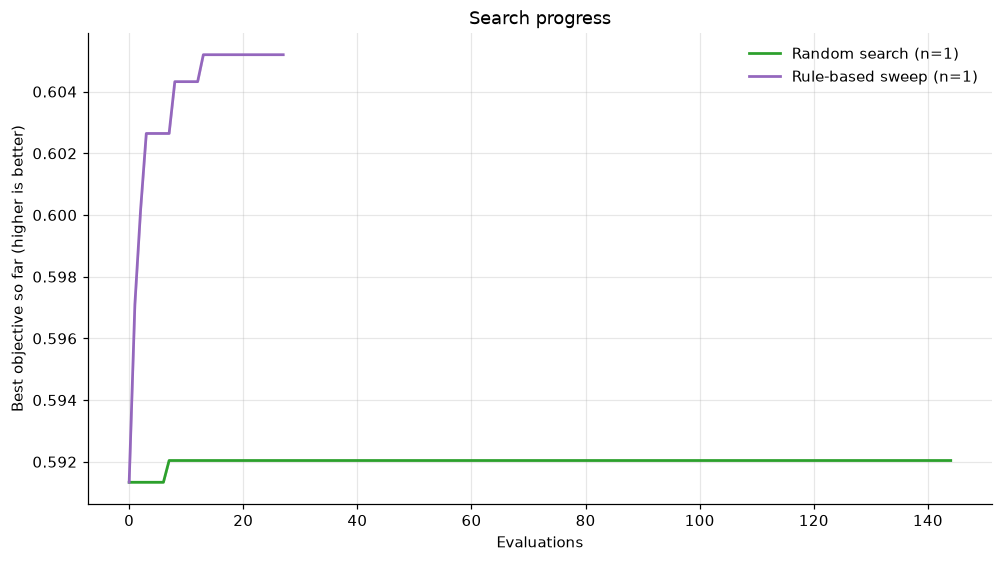

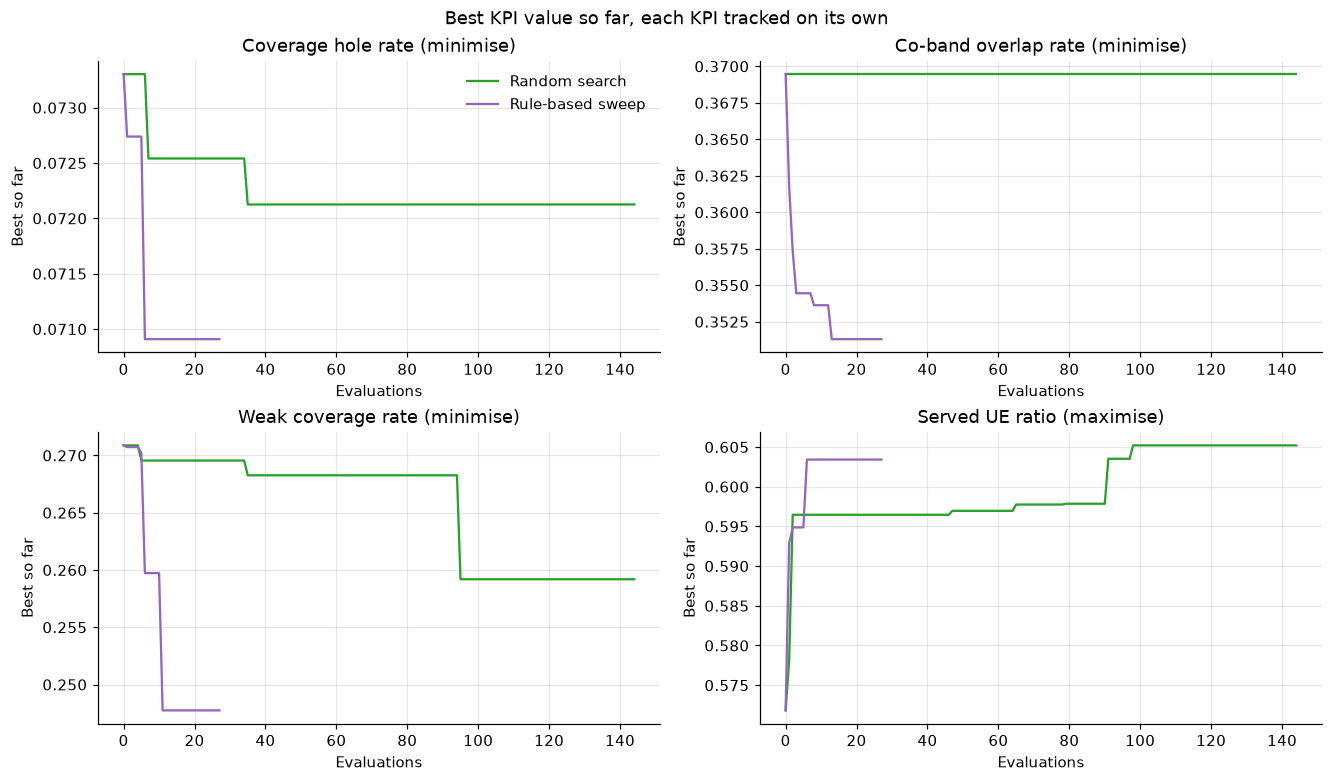

In [8]:
trace = compare.convergence(runs)
figure = plots.convergence_plot(trace)
save_fig(figure, "search_progress")
plt.show()

figure, axes = plt.subplots(2, 2, figsize=(12.0, 7.0), constrained_layout=True)
for axis, name in zip(axes.ravel(), ("hole_rate", "overlap_rate", "weak_rate", "served_ratio"), strict=True):
    part = trace[trace["kpi"] == name]
    for method, group in part.groupby("method", sort=False):
        mean = group.groupby("iteration")["value"].mean()
        axis.plot(mean.index, mean.to_numpy(), color=plots.COLOURS.get(method), label=label(method))
    axis.set_title(f"{label(name)} ({compare.direction(name)})")
    axis.set_xlabel("Evaluations")
    axis.set_ylabel("Best so far")
axes[0, 0].legend()
figure.suptitle("Best KPI value so far, each KPI tracked on its own")
save_fig(figure, "kpi_progress")
plt.show()

Each KPI panel tracks that KPI's own best value, which need not come from the configuration with the best J.

**Observations.** Random search found its best configuration at evaluation 7, inside the Sobol initial design, and
none of the later draws beat it; its best J (0.592) is barely above the current configuration's (0.591). The
rule-based sweep's first pass over the three bands supplies nearly its whole gain (0.604 after 10 evaluations), and
it ends at 0.605 after 28 evaluations, above random search at a fraction of the ray-tracing cost.

## 9. Best Tilt Configuration

The deliverable of each method's best run: current and proposed tilt per cell-band. Negative change is uptilt.

Random search: run 2026-09-17_13-46-51, seed 42, best evaluation 7


,Band,Cells,Cells moved,Mean absolute tilt change [°],Largest tilt change [°],Mean tilt change [°]
0,1800 MHz,12,12,4.6330,8.3717,-2.8540
1,2600 MHz,12,12,6.7463,11.5816,-6.7463
2,700 MHz,12,12,3.0438,5.6712,-0.6057


,Cell,Band,Current tilt [°],Proposed tilt [°],Tilt change [°],Minimum tilt [°],Maximum tilt [°]
0,n0c0,2600 MHz,12.0,6.0149,-5.9851,0.0,15.0
1,n0c0,1800 MHz,9.0,2.7582,-6.2418,0.0,15.0
2,n0c0,700 MHz,6.0,7.3027,1.3027,0.0,15.0
3,n0c1,2600 MHz,12.0,11.1984,-0.8016,0.0,15.0
4,n0c1,1800 MHz,9.0,2.0915,-6.9085,0.0,15.0
5,n0c1,700 MHz,6.0,11.0507,5.0507,0.0,15.0
6,n0c2,2600 MHz,12.0,4.5229,-7.4771,0.0,15.0
7,n0c2,1800 MHz,9.0,8.1376,-0.8624,0.0,15.0
8,n0c2,700 MHz,6.0,1.7780,-4.2220,0.0,15.0
9,n1c0,2600 MHz,12.0,11.8575,-0.1425,0.0,15.0


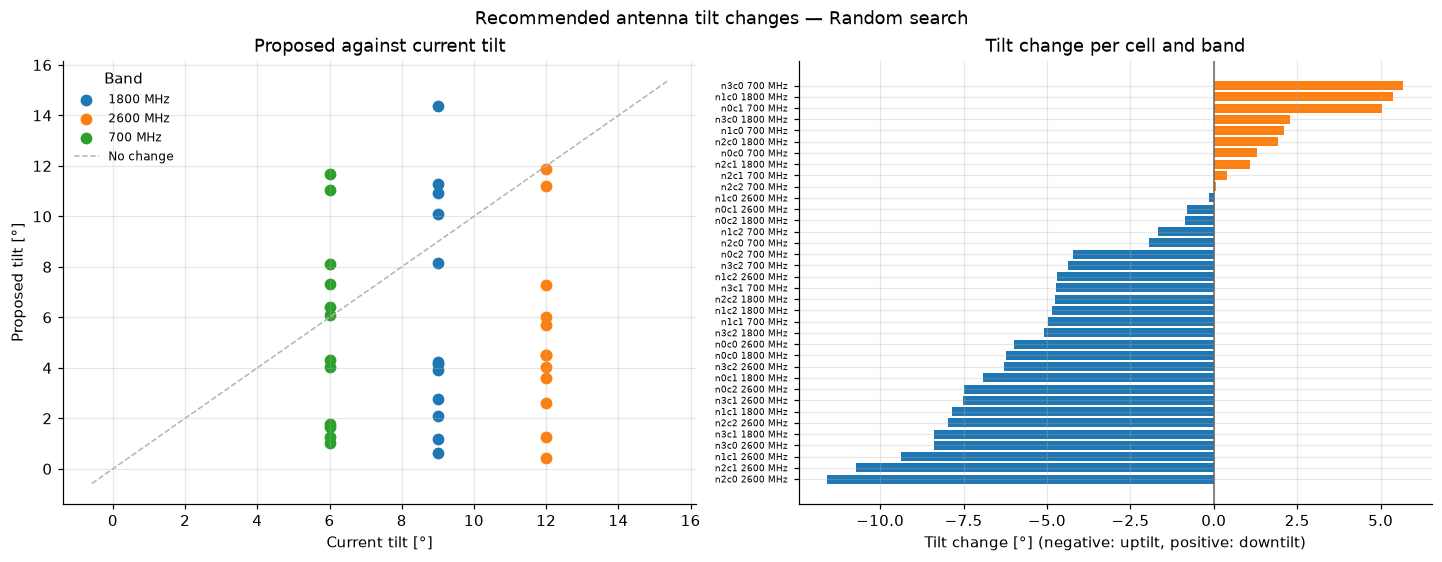

Rule-based sweep: run 2026-09-17_13-55-32, seed 42, best evaluation 13


,Band,Cells,Cells moved,Mean absolute tilt change [°],Largest tilt change [°],Mean tilt change [°]
0,1800 MHz,12,12,1.5,1.5,-1.5
1,2600 MHz,12,12,4.5,4.5,-4.5
2,700 MHz,12,12,1.5,1.5,1.5


,Cell,Band,Current tilt [°],Proposed tilt [°],Tilt change [°],Minimum tilt [°],Maximum tilt [°]
0,n0c0,2600 MHz,12.0,7.5,-4.5,0.0,15.0
1,n0c0,1800 MHz,9.0,7.5,-1.5,0.0,15.0
2,n0c0,700 MHz,6.0,7.5,1.5,0.0,15.0
3,n0c1,2600 MHz,12.0,7.5,-4.5,0.0,15.0
4,n0c1,1800 MHz,9.0,7.5,-1.5,0.0,15.0
5,n0c1,700 MHz,6.0,7.5,1.5,0.0,15.0
6,n0c2,2600 MHz,12.0,7.5,-4.5,0.0,15.0
7,n0c2,1800 MHz,9.0,7.5,-1.5,0.0,15.0
8,n0c2,700 MHz,6.0,7.5,1.5,0.0,15.0
9,n1c0,2600 MHz,12.0,7.5,-4.5,0.0,15.0


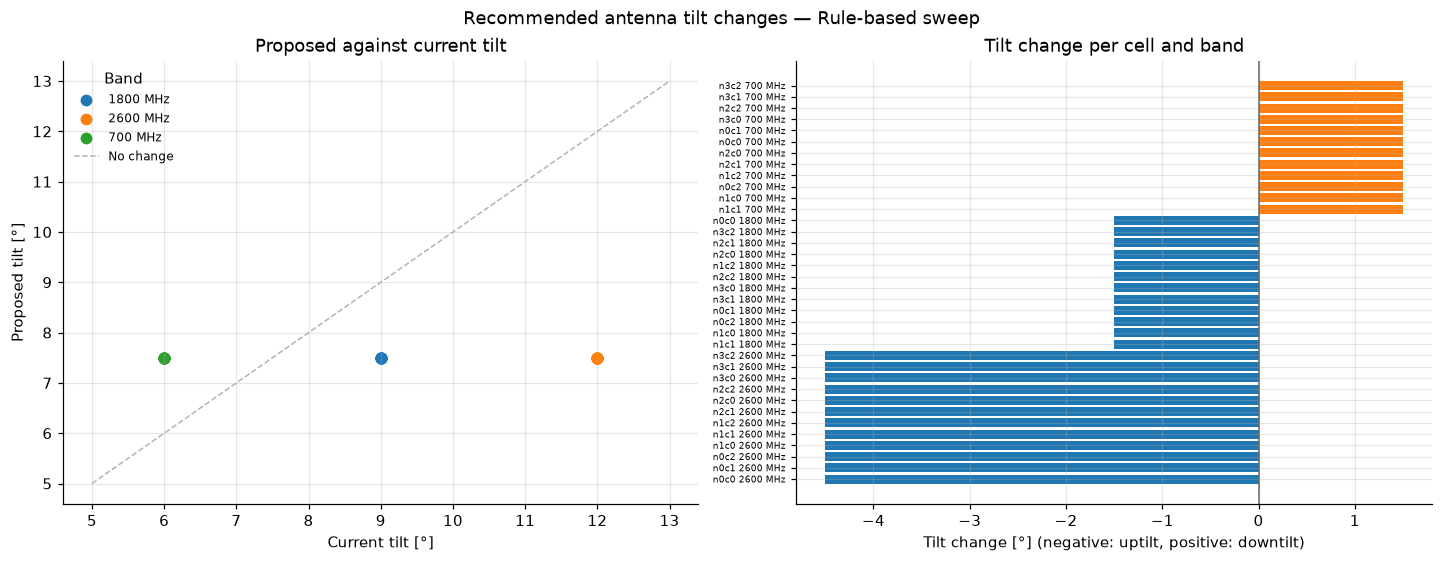

In [9]:
for method in METHODS:
    chosen = best[method]
    tilt = readable(chosen.best_tilt)
    save_table(tilt, f"best_tilt_{method}")
    summary = readable(compare.tilt_movement(chosen))
    save_table(summary, f"tilt_movement_{method}")
    print(f"{label(method)}: run {chosen.run_id}, seed {chosen.seed}, best evaluation {chosen.best_index}")
    display(summary)
    display(tilt)
    figure = plots.tilt_movement_plot(chosen.best_tilt, method)
    save_fig(figure, f"tilt_movement_{method}")
    plt.show()

**Observations.** The sweep sets every cell to 7.5° on every band: 4.5° of uptilt on 2600 MHz, 1.5° of uptilt on
1800 MHz and 1.5° of downtilt on 700 MHz, since it can only move bands as a whole. Random search's best point uptilts
2600 MHz by 6.7° on average and moves the other bands both ways, by amounts that vary from almost nothing to more than
8° with no visible pattern by node. That spread is what one Sobol draw looks like, not evidence that those cells need
different tilts.

## 10. Final Results

### KPI comparison

Each method's best configuration against the current one, on every UE. Relative improvement is signed so that
positive is better whichever direction the KPI runs:

$$
\text{Improvement} = s \cdot \frac{KPI_\text{optimized} - KPI_\text{initial}}{|KPI_\text{initial}|} \times 100\%,
\qquad s = \begin{cases} +1 & \text{maximised} \\ -1 & \text{minimised} \end{cases}
$$

In [10]:
def kpi_comparison(chosen):
    table = compare.delta_table(chosen.incumbent_kpi, chosen.best_kpi)
    sign = np.where(table["kpi"].isin(MAXIMISED), 1.0, -1.0)
    table["improvement_pct"] = 100.0 * sign * table["delta"] / table["before"].abs()
    return table


for method in METHODS:
    table = readable(kpi_comparison(best[method])).rename(
        columns={
            "direction": "Direction",
            "before": "Initial",
            "after": label(method),
            "delta": "Change",
            "verdict": "Verdict",
            "improvement_pct": "Improvement [%]",
        }
    )
    save_table(table, f"kpi_comparison_{method}")
    print(label(method))
    display(table)

cost = readable(compare.method_table(runs).drop(columns=["run"]))
save_table(cost, "baseline_results")
cost

Random search


,KPI,Direction,Initial,Random search,Change,Verdict,Improvement [%]
0,Coverage hole rate,minimise,0.0733,0.0725,-0.0008,better,1.0394
1,Co-band overlap rate,minimise,0.3695,0.3740,0.0045,worse,-1.2159
2,Served UE ratio,maximise,0.5718,0.5939,0.0221,better,3.8568
3,Weak coverage rate,minimise,0.2709,0.2775,0.0066,worse,-2.4475
4,Cell-edge RSRP,maximise,-105.6556,-105.8053,-0.1498,worse,-0.1418
5,Objective J,maximise,0.5913,0.5920,0.0007,better,0.1193


Rule-based sweep


,KPI,Direction,Initial,Rule-based sweep,Change,Verdict,Improvement [%]
0,Coverage hole rate,minimise,0.0733,0.0732,-5.9371e-05,better,0.0810
1,Co-band overlap rate,minimise,0.3695,0.3513,-1.8158e-02,better,4.9146
2,Served UE ratio,maximise,0.5718,0.5862,1.4405e-02,better,2.5191
3,Weak coverage rate,minimise,0.2709,0.2845,1.3586e-02,worse,-5.0155
4,Cell-edge RSRP,maximise,-105.6556,-105.8603,-2.0476e-01,worse,-0.1938
5,Objective J,maximise,0.5913,0.6052,1.3861e-02,better,2.3439


,Method,Seed,Evaluations,Best evaluation,Ray tracing [min],Wall clock [min],Coverage hole rate,Co-band overlap rate,Served UE ratio,Weak coverage rate,Cell-edge RSRP,Objective J,KPIs improved,KPIs worsened
0,Random search,42,145,7,7.5981,8.6798,0.0725,0.3740,0.5939,0.2775,-105.8053,0.5920,3,3
1,Rule-based sweep,42,28,13,0.9097,1.1755,0.0732,0.3513,0.5862,0.2845,-105.8603,0.6052,4,2


**Observations.** Both baselines raise J and the served UE ratio, and both slightly worsen weak coverage and
cell-edge RSRP. The rule-based sweep gains more on J (+2.3 % against +0.1 %) by cutting the co-band overlap rate from
0.369 to 0.351, while random search raises overlap to 0.374 and gains more on the served ratio (0.594 against 0.586)
and the hole rate. Neither method changes any KPI by more than a few percent relative.

## 11. Coverage Map Comparison

Best-server RSRP before and after, and the tiles that crossed the coverage-hole threshold; then the RSRP change of
each method's best configuration. Crimson triangles are the masts.

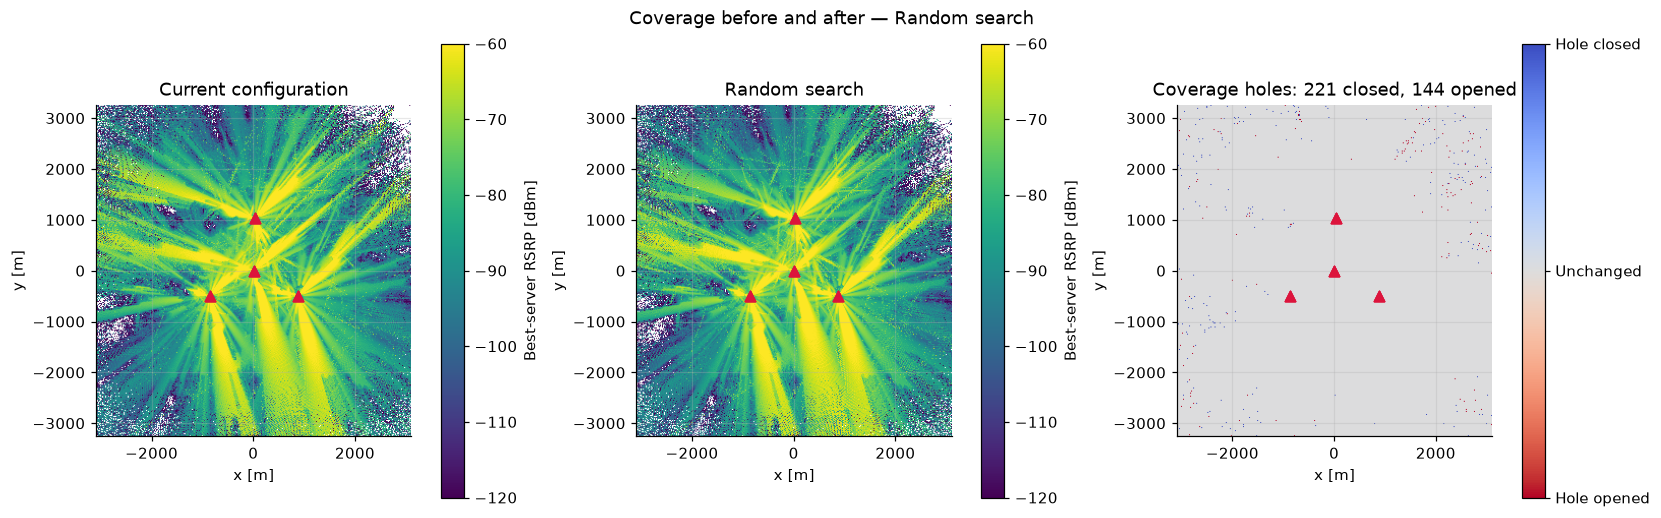

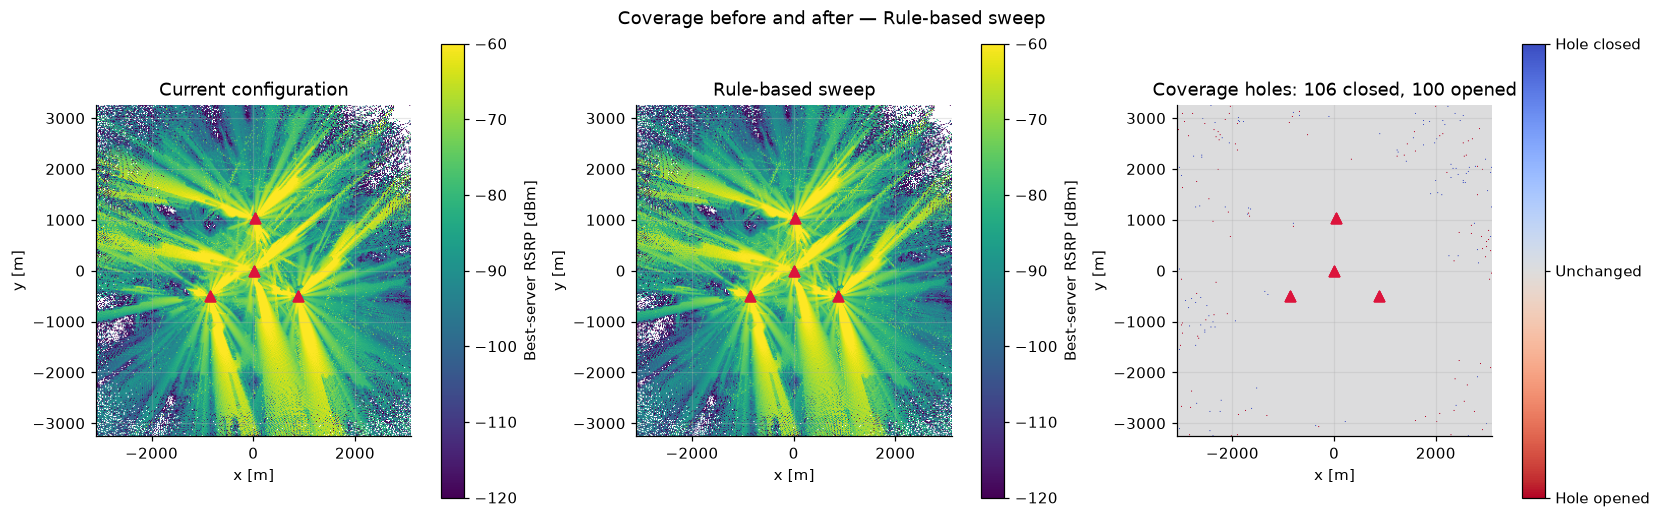

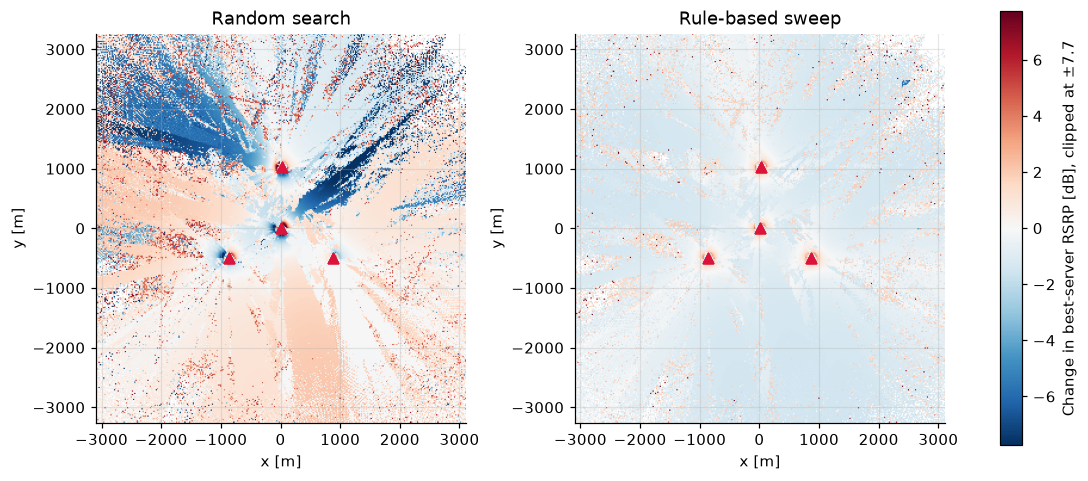

In [11]:
best_rsrp = {"incumbent": max_rsrp(baseline_rsrp)}
best_rsrp.update({method: max_rsrp(best[method].radio_map["rsrp_dbm"].astype(float)) for method in METHODS})

for method in METHODS:
    figure = plots.coverage_maps(
        best_rsrp["incumbent"], best_rsrp[method], baseline, cfg, cells=cells, name=method
    )
    save_fig(figure, f"coverage_before_after_{method}")
    plt.show()

# No path in either map makes the change undefined; it stays blank.
with np.errstate(invalid="ignore"):
    change = {label(m): best_rsrp[m] - best_rsrp["incumbent"] for m in METHODS}
figure = plots.map_row(
    change, baseline, colorbar_label="Change in best-server RSRP [dB]", symmetric=True, cells=cells
)
save_fig(figure, "rsrp_change_maps")
plt.show()

Regions worth inspecting: the cell edges between the three corner nodes and the centre node, the tiles that opened or
closed a hole, and heavily overlapped areas near the masts.

**Observations.** The two baselines move RSRP in opposite directions. The sweep lowers best-server RSRP on most tiles
(a median of about 1 dB beyond 300 m from a node), because 700 MHz, the strongest layer almost everywhere, is
downtilted; its gain in J comes from less overlap, not more signal. Random search raises RSRP on 55 % of tiles, by a
median of about 0.3–0.5 dB beyond 1 km. Hole changes are small either way: the sweep closes 106 hole tiles and opens
100, random search closes 221 and opens 144.

## 12. KPI-Level Analysis

Coverage classes by area and by demand, overlap, and which band serves the UEs. Demand is the incumbent's, for every
configuration, so the weights do not move. The project has no band-priority score; the serving-band mix is read
against the preference order `kpi.capacity.band_preference` instead.

,Coverage class,Current configuration: Share of area,Current configuration: Share of demand,Random search: Share of area,Random search: Share of demand,Rule-based sweep: Share of area,Rule-based sweep: Share of demand
0,hole,0.0733,0.0000,0.0725,0.0072,0.0732,0.0040
1,weak,0.2709,0.8099,0.2775,0.8055,0.2845,0.8301
2,good,0.6558,0.1901,0.6500,0.1873,0.6423,0.1658


,Configuration,Co-band overlap rate,Mean overlapping neighbours
0,Current configuration,0.3695,1.1892
1,Random search,0.3740,1.2088
2,Rule-based sweep,0.3513,1.1065


Band preference, most preferred first: 2600 MHz, 1800 MHz, 700 MHz


,Configuration,UE reports,Share not served,"Served SINR, 10th percentile [dB]","Served SINR, median [dB]","PRBs per served UE, median",Share served on 2600 MHz,Share served on 1800 MHz,Share served on 700 MHz
0,Current configuration,10066.0,0.4282,-0.7549,4.5212,57.3283,0.3722,0.1106,0.0890
1,Random search,10066.0,0.4061,-0.3073,6.6999,44.3526,0.4594,0.0617,0.0728
2,Rule-based sweep,10066.0,0.4138,-0.5622,5.7317,49.4777,0.4612,0.0537,0.0713


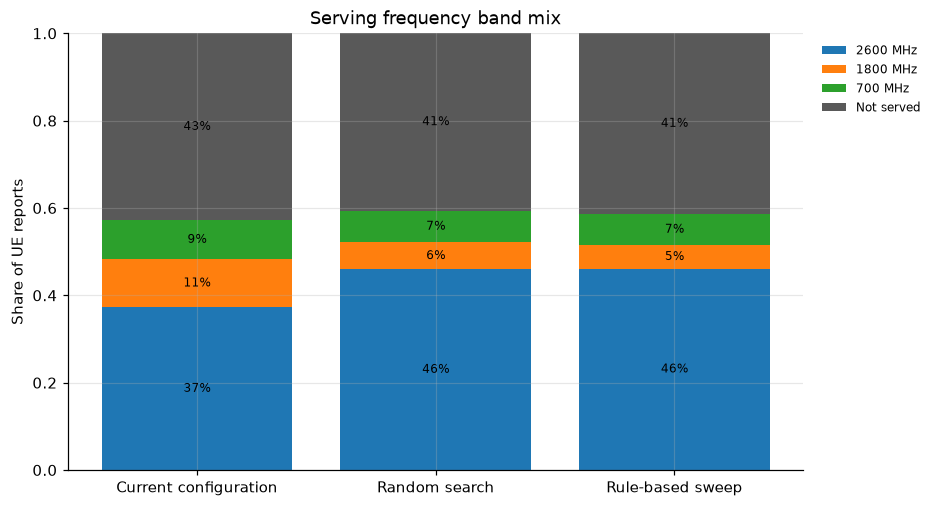

In [12]:
configurations = {"incumbent": compare.configuration(baseline, ue, cfg)}
configurations.update({m: compare.configuration(best[m].radio_map, ue, cfg) for m in METHODS})
demand = configurations["incumbent"].demand

coverage = compare.coverage_comparison(
    {name: maps.coverage_table(c.rsrp, demand, cfg) for name, c in configurations.items()}
)
coverage.columns = ["coverage"] + [
    f"{label(key)}: {label(f'{share}_share')}"
    for key, share in (column.rsplit("_", 1) for column in coverage.columns[1:])
]
coverage = readable(coverage)
save_table(coverage, "coverage_by_area_and_demand")
display(coverage)

overlap = pd.DataFrame(
    {
        "configuration": list(configurations),
        "overlap_rate": [runs[0].incumbent_kpi.overlap_rate]
        + [best[m].best_kpi.overlap_rate for m in METHODS],
        "Mean overlapping neighbours": [mean_overlap_neighbors(c.rsrp) for c in configurations.values()],
    }
)
overlap = readable(overlap)
save_table(overlap, "overlap")
display(overlap)

band_labels = [str(band) for band in baseline["band_label"]]
print("Band preference, most preferred first:", ", ".join(label(b) for b in cfg.kpi.capacity.band_preference))
service = {name: compare.service_summary(c.served, band_labels) for name, c in configurations.items()}
service_table = readable(pd.DataFrame(service).T.rename_axis("configuration").reset_index())
save_table(service_table, "ue_service_summary")
display(service_table)
figure = plots.band_share_bars(service, band_labels)
save_fig(figure, "serving_band_mix")
plt.show()

### Coverage holes

The hole rate barely moves by area (0.073 for all three configurations). The current configuration has no demand on
hole tiles; random search moves 0.7 % of demand onto holes and the sweep 0.4 %.

### Coverage overlap

The sweep lowers the overlap rate and the mean number of overlapping neighbours over covered tiles (1.19 to 1.11);
random search raises both (to 1.21) but lowers the share of tiles with three or more neighbours.

### Multi-band coordination

The share of UE reports served on 2600 MHz, the preferred band, grows from 37 % to 46 % for both methods, while the
1800 MHz share falls from 11 % to 5–6 % and 700 MHz from 9 % to 7 %. The served ratio still rises, and served SINR
improves at the median and the 10th percentile.

### Weak coverage

Weak coverage rises slightly by area for both methods (27.1 % to 27.8 % and 28.4 %). Most demand still sits on weak
tiles for all three configurations (81 % currently, 83 % under the sweep).

## 13. Key Observations

- The current per-band tilts (12°, 9°, 6°) leave little for either baseline to gain on this objective: +2.3 % for the
  sweep and +0.1 % for random search.
- A structured three-variable sweep beat unstructured 36-variable random search on J, at a fraction of the
  ray-tracing cost; the random budget is spread too thinly over the tilt box to add anything after the initial design.
- The sweep's gain comes from less co-band overlap at slightly weaker signal, so the KPIs trade off against each other.
- These are one seed on one scenario; notebook 04 reports intervals over seeds.

## 14. Baseline Limitations

- **Random search** does not model the objective landscape or reuse what earlier evaluations revealed; with 36
  variables, a fixed budget covers the box only sparsely.
- **The rule-based sweep** cannot give cells on one band different tilts, so it cannot fix a local problem without
  moving every cell on that band, and coordinate descent stops at the first configuration no single band can improve.
- Every candidate costs a full ray trace, so either method's result depends on the budget it was given.
- The winner is the best of many evaluations under one solver seed, so its score is biased upward (notebook 04,
  threats to validity).
- Neither method constrains how far an antenna moves; tilt change is reported, not penalised.

These limitations motivate a sample-efficient, model-guided search.

## 15. Baselines vs. the Proposed Method

| Property | Random search | Rule-based sweep | TuRBO (notebook 03b) |
| --- | --- | --- | --- |
| Search strategy | Sobol sampling over the box | Shared tilt per band, coordinate descent | Trust-region Bayesian optimization |
| Surrogate model | No | No | Gaussian process |
| Uses previous evaluations | No | Only the current best | Yes, to fit the model and move the trust region |
| High-dimensional search | Uniform coverage, thins with dimension | Collapses 36 variables to 3 | Local trust region around the best point |
| Simulations | `n_init + n_iter` | `n_band · n_steps · n_rounds` at most | `n_init + n_iter`, as random search |
| Best objective | Section 10 | Section 10 | Notebook 04 |

All three share the initial network state, simulator, scenario, constraints and objective; random search and TuRBO
also share the evaluation budget and the initial Sobol design. The comparison with confidence intervals over seeds is
in notebook 04.

## 16. Conclusion

The baselines set a reproducible reference for multi-band tilt optimization on this scenario. They show:

- the improvement a simple strategy reaches, led by the rule-based sweep;
- how tilt drives the objective: the sweep gains by cutting co-band overlap, not by extending coverage;
- the trade-off between overlap and signal strength;
- that unstructured search over the 36-dimensional tilt space is inefficient at this budget.

TuRBO (notebook 03b) has to beat the rule-based sweep, not just random search, to justify its cost; notebook 04
makes that comparison.